In [1]:
from shapely.geometry import shape
import json
import pandas as pd
from scipy.signal import detrend
import geopandas as gpd
import pandas as pd

In [ ]:
# df = pd.read_parquet("data/dataset.parquet")
PID_df=pd.read_csv('data/lookup/PID_location_all.csv')


In [3]:
PID_df["managed"] = PID_df["managed"].fillna(-1)
PID_df["ownership"] = PID_df["ownership"].fillna("No Data")
PID_df["biome"] = PID_df["biome"].fillna("No Data")
PID_df = PID_df[PID_df["lon"] <= 0]
PID_df = PID_df[PID_df["lat"] > 22]

In [4]:
csc_df.rename(columns={'PID_left': "PID"}, inplace= True)
csc_df.drop(columns=['Unnamed: 0'], inplace=True)

csc_df=csc_df.merge(PID_df, on='PID', how='inner')

## Preprocessing 


In [5]:
def autocorr_pid(group, max_lag=1):
    group = group.sort_values('year')
    acfs = [group['Npp'].autocorr(lag=1)]
    return pd.Series(acfs, index=[f'ACF_lag{lag}' for lag in range(1, max_lag+1)])


In [6]:
def detrend_pid(group):
    # Sort by year
    group = group.sort_values('year')
    # Detrend NPP
    group['NPP_detrended'] = detrend(group['Npp'].values)
    return group



In [7]:
df_joined=pd.read_csv('data/processed/PID_npp.csv')

# df_joined = df_joined.groupby('PID').apply(detrend_pid).reset_index(drop=True)
df_joined.drop(columns=(['Unnamed: 0']), inplace=True)

autocorr_df = df_joined.groupby('PID').apply(autocorr_pid).reset_index()
df= autocorr_df[["PID", "ACF_lag1"]]
# autocorr_df["std"] = autocorr_df.drop(columns=["PID"]).std(axis=1)
# df= autocorr_df[["PID", "std"]]
# df = df.rename(columns={"st": "TAC_NPP"})


/home/qli/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/qli/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/qli/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/qli/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/tmp/ipykernel_1828736/3468764466.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping co

In [8]:
df = df.rename(columns={"ACF_lag1": "TAC_NPP"})
df_joined=df

total_df = df.merge(PID_df, on='PID', how='inner')
total_df.dropna(subset=["TAC_NPP"], inplace=True)

In [ ]:
total_df.to_csv('data/processed/npp_tac.csv', index=False)

## Visualisation Part 1


In [ ]:
# import matplotlib.pyplot as plt
# sample_vals = df_joined["PID"].sample(5, replace=False)
# filtered_df = df_joined[df_joined["PID"].isin(sample_vals)]
# pid_codes = filtered_df["PID"].astype("category").cat.codes
# plt.figure(figsize=(10,5))

# for pid, g in filtered_df.groupby("PID"):
#     g = g.sort_values("year")
#     plt.plot(g["year"], g["TAC_NPP"], label=pid)

# plt.xlabel("Year")
# plt.ylabel("Npp")
# plt.title("NPP Time Series by PID")
# plt.legend(title="PID", bbox_to_anchor=(1.05, 1))
# plt.tight_layout()
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# # sample_vals = df_joined["PID"].sample(5, replace=False)
# # filtered_df = df_joined[df_joined["PID"].isin(sample_vals)]
# # pid_codes = filtered_df["PID"].astype("category").cat.codes
# plt.figure(figsize=(10,5))

# for pid, g in filtered_df.groupby("PID"):
#     g = g.sort_values("year")
#     plt.plot(g["year"], g["Npp"], label=pid)

# plt.xlabel("Year")
# plt.ylabel("Npp")
# plt.title("NPP Time Series by PID")
# plt.legend(title="PID", bbox_to_anchor=(1.05, 1))
# plt.tight_layout()
# plt.show()

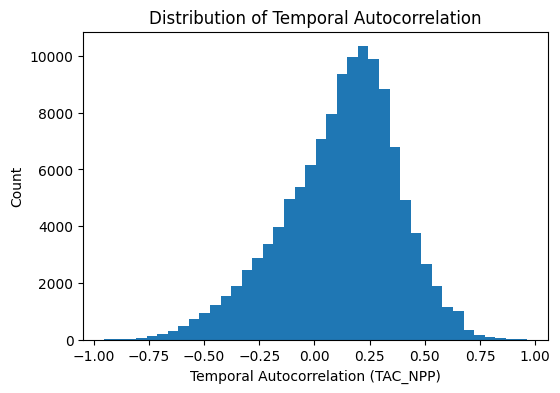

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["TAC_NPP"], bins=40)
plt.xlabel("Temporal Autocorrelation (TAC_NPP)")
plt.ylabel("Count")
plt.title("Distribution of Temporal Autocorrelation")
plt.show()

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter(total_df["lon"], total_df["lat"], c=total_df["TAC_NPP"], s=1, cmap= 'PiYG')
plt.colorbar(label="TAC_NPP")
plt.title("Spatial Pattern of Temporal Autocorrelation")
plt.show()

NameError: name 'total_df' is not defined

<Figure size 1200x500 with 0 Axes>

In [ ]:
count_A1 = ((total_df['managed'] == 1.0) & (total_df['TAC_NPP'] < 0)).sum()
print("Number of managed forests with declining NPP<0:", count_A1)

counts = total_df['managed'].value_counts()
num_negative = (total_df['TAC_NPP'] < 0).sum()

print(f'number of managed forests{counts} and number of declining NPP<0: {num_negative}')

Number of managed forests with declining NPP<0: 466491


In [ ]:

# Assign a color to each forest type
forest_colors = {
    'Temperate conifer forests': 'lightgreen',
    'Temperate grasslands': 'lightblue',
    'Xeric shrublands': 'wheat',
    'Mediterranean woodlands': 'orange',
    'Tropical coniferous forests': 'darkgreen',
    'No Data': 'gray'
}

managed= {
    1.0: 'blue',
    0.0: 'red',
    -1.0: 'gray'
}

ownership = {
    'national_forest': 'darkblue',
    'other': 'lightgray',
    'state': 'lightgreen',
    'blm': 'orange',
    'national_park': 'darkgreen',
    'local': 'purple',
    'other_federal': 'brown',
    'fish_wildlife': 'pink',
    'dod': 'gray',
    'other_forest_service': 'lightblue',
    'national_grassland': 'yellow',
    'No Data': 'gray'

}


In [ ]:
df_managed = total_df[total_df["managed"] == 1.0]

In [ ]:
df_managed

,PID,TAC_NPP,lat,lon,BHAGE,managed,ownership,biome
0,0_41_27_17_550,0.335842,45.460278,-121.751396,50.0,1.0,other,Temperate conifer forests
1,0_41_27_17_550,0.335842,45.460278,-121.751396,51.0,1.0,other,Temperate conifer forests
2,0_41_27_17_550,0.335842,45.460278,-121.751396,56.0,1.0,other,Temperate conifer forests
3,0_41_27_17_550,0.335842,45.460278,-121.751396,56.0,1.0,other,Temperate conifer forests
4,0_41_27_17_550,0.335842,45.460278,-121.751396,48.0,1.0,other,Temperate conifer forests
...,...,...,...,...,...,...,...,...
7144266,9_53_75_72668_501,0.275722,47.208802,-117.640824,84.0,1.0,other,Temperate grasslands
7144267,9_53_75_72668_501,0.275722,47.208802,-117.640824,NaN,1.0,other,Temperate grasslands
7144275,9_53_75_72668_501,0.275722,47.208802,-117.640824,NaN,1.0,other,Temperate grasslands
7144278,9_53_75_72668_501,0.275722,47.208802,-117.640824,NaN,1.0,other,Temperate grasslands


/tmp/ipykernel_1826000/1656914146.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


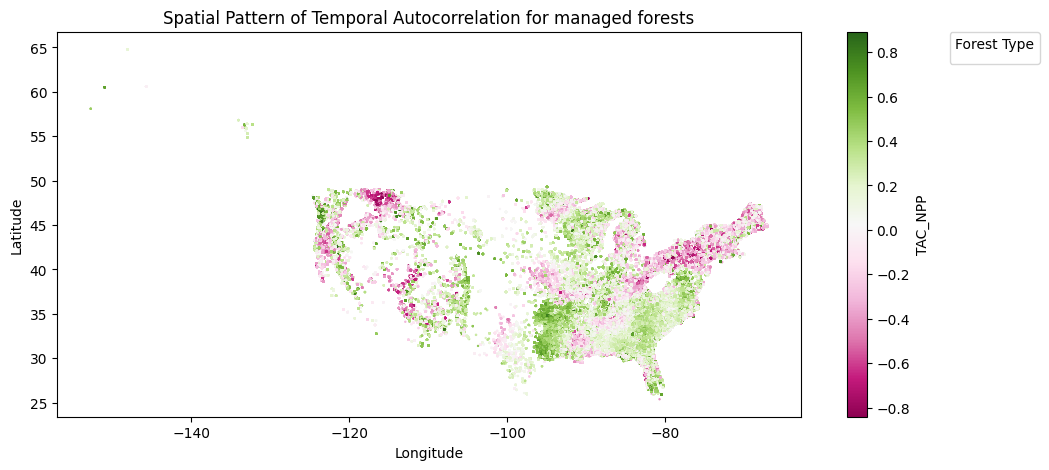

In [ ]:
plt.figure(figsize=(12,5))

sc = plt.scatter(
    df_managed["lon"], 
    df_managed["lat"], 
    c=df_managed["TAC_NPP"], 
    s=0.5, 
    cmap='PiYG'
)

plt.colorbar(sc, label="TAC_NPP")

plt.title("Spatial Pattern of Temporal Autocorrelation for managed forests")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    title="Forest Type",
    bbox_to_anchor=(1.2, 1),  # x=1.05 moves it right outside axes
    loc='upper left',           # anchors the legend's upper-left corner
    borderaxespad=0            # padding between axes and legend
)
plt.show()

plt.show()

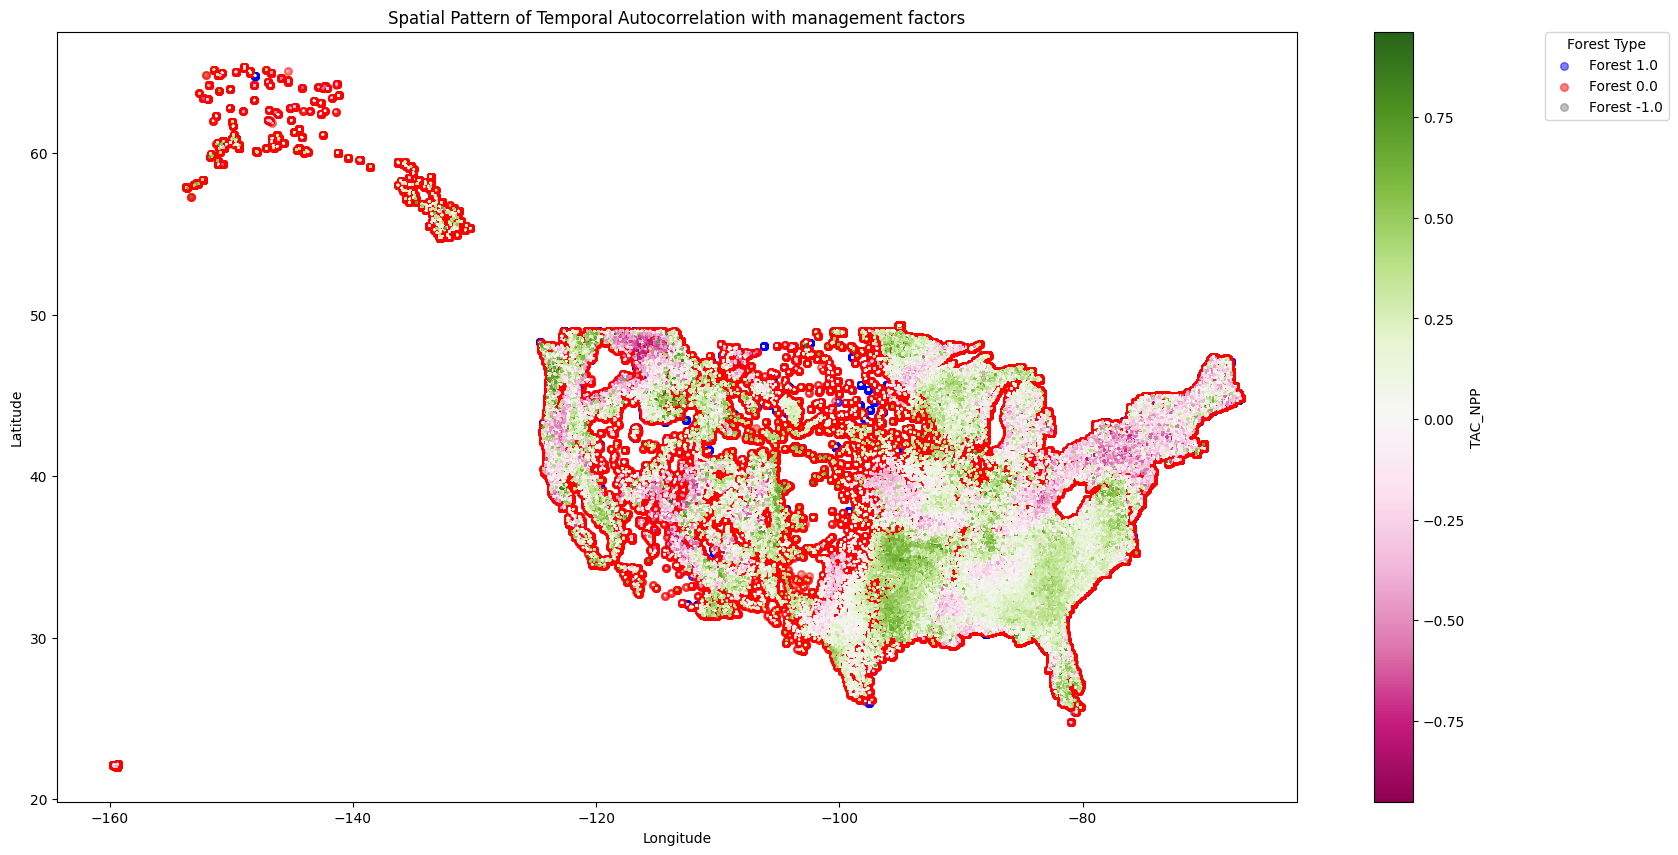

In [ ]:
plt.figure(figsize=(20,10))

for ftype, color in managed.items():
    subset = total_df[total_df["managed"] == ftype]
    plt.scatter(
        subset["lon"], 
        subset["lat"], 
        color=color, 
        alpha=0.5,  # transparency
        s=30, 
        label=f"Forest {ftype}"
    )

# First, scatter points colored by TAC_NPP
sc = plt.scatter(
    total_df["lon"], 
    total_df["lat"], 
    c=total_df["TAC_NPP"], 
    s=0.5, 
    cmap='PiYG'
)
plt.colorbar(sc, label="TAC_NPP")

plt.title("Spatial Pattern of Temporal Autocorrelation with management factors")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    title="Forest Type",
    bbox_to_anchor=(1.2, 1),  # x=1.05 moves it right outside axes
    loc='upper left',           # anchors the legend's upper-left corner
    borderaxespad=0            # padding between axes and legend
)
plt.show()

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter(csc_df["lon"], csc_df["lat"], c=csc_df["csc"], s=1, cmap= 'Greens')
plt.colorbar(label="TAC_NPP")
plt.title("Spatial Pattern of CSC")
plt.show()

## Visualisations Part 2

In [1]:
from shapely.geometry import shape
import json
import pandas as pd
from scipy.signal import detrend
import geopandas as gpd
import pandas as pd

In [ ]:
csc_df= pd.read_csv('data/processed/PID_csc_upsampled.csv')
npp_df = pd.read_csv('data/processed/npp_tac.csv')


In [ ]:
csc_df.rename(columns={'PID_left': "PID"}, inplace= True)
csc_df.drop(columns=['Unnamed: 0'], inplace=True)



In [4]:
merged_df = npp_df.merge(csc_df, on='PID', how='left', suffixes=('_','_orig'))
merged_df = merged_df.drop(columns=[col for col in merged_df.columns if "orig" in col])
merged_df.dropna(subset=['csc', 'TAC_NPP'], inplace=True)

normalized = (merged_df['csc']-min(merged_df['csc']))/(max(merged_df['csc'])-min(merged_df['csc']))
merged_df['Stability metric'] = normalized + merged_df["TAC_NPP"]

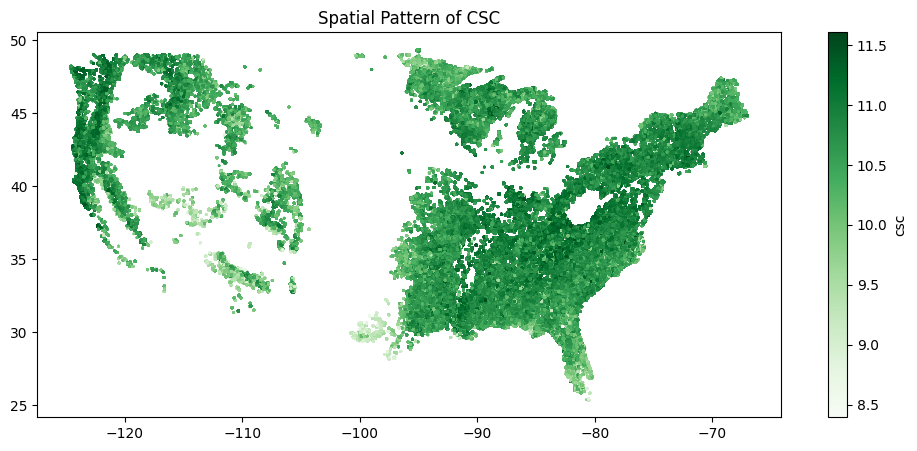

In [11]:
plt.figure(figsize=(12,5))
plt.scatter(merged_df["lon"], merged_df["lat"], c=merged_df["csc"], s=1, cmap= 'Greens')
plt.colorbar(label="csc")
plt.title("Spatial Pattern of CSC")
plt.show()

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from shapely.geometry import box


normalized = (merged_df['csc']-min(merged_df['csc']))/(max(merged_df['csc'])-min(merged_df['csc']))
merged_df['Stability metric'] = normalized + merged_df["TAC_NPP"]

# Pink → white → green
cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#F40D0D", "#CADDD6", "#075706"]  # pink, zero, positive
)

norm = mcolors.TwoSlopeNorm(
    vmin=merged_df['Stability metric'].min(),
    vcenter=0.2,
    vmax=merged_df["Stability metric"].max()
)

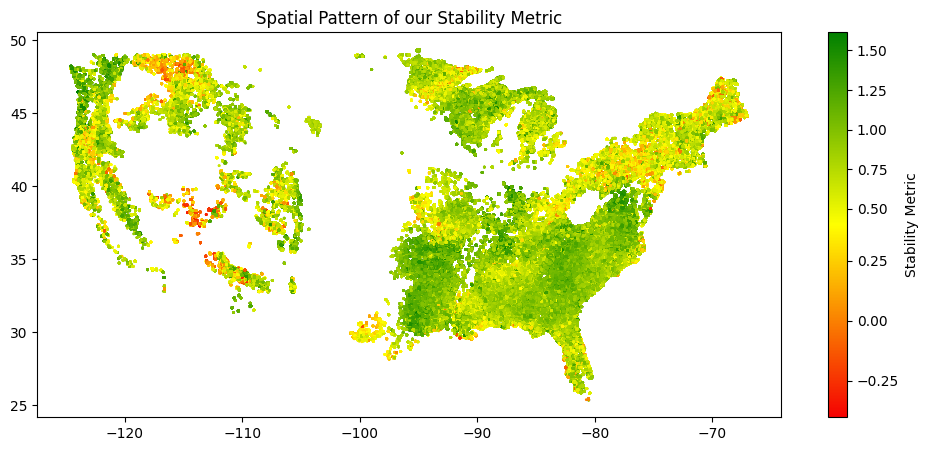

In [ ]:


plt.figure(figsize=(12,5))
plt.scatter(merged_df["lon"], merged_df["lat"], c=merged_df["Stability metric"], s=1, cmap=cmap, norm=norm)
plt.colorbar(label="Stability Metric")
plt.title("Spatial Pattern of our Stability Metric")
plt.show()

In [14]:
count_A1 = ((merged_df['managed'] == 1.0) & (merged_df['Stability metric'] < 0.2)).sum()
print("Number of managed forests with declining NPP<0:", count_A1)

counts = merged_df['managed'].value_counts()
num_negative = (merged_df['Stability metric'] < 0.2).sum()

print(f'number of managed forests{counts} and number of declining NPP<0: {num_negative}')

Number of managed forests with declining NPP<0: 13473
number of managed forestsmanaged
0.0    2472709
1.0    1327170
Name: count, dtype: int64 and number of declining NPP<0: 68252


In [46]:
merged_df

,PID,TAC_NPP,lat,lon,BHAGE,managed,ownership,biome,csc,Stability metric
0,0_41_27_17_550,0.335842,45.460278,-121.751396,50.0,1.0,other,Temperate conifer forests,10.687259,1.049213
1,0_41_27_17_550,0.335842,45.460278,-121.751396,51.0,1.0,other,Temperate conifer forests,10.687259,1.049213
2,0_41_27_17_550,0.335842,45.460278,-121.751396,56.0,1.0,other,Temperate conifer forests,10.687259,1.049213
3,0_41_27_17_550,0.335842,45.460278,-121.751396,56.0,1.0,other,Temperate conifer forests,10.687259,1.049213
4,0_41_27_17_550,0.335842,45.460278,-121.751396,48.0,1.0,other,Temperate conifer forests,10.687259,1.049213
...,...,...,...,...,...,...,...,...,...,...
7074307,9_53_71_93609_501,-0.558254,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,10.924962,0.229060
7074308,9_53_71_93609_501,-0.558254,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,10.924962,0.229060
7074309,9_53_71_93609_501,-0.558254,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,10.924962,0.229060
7074310,9_53_71_93609_501,-0.558254,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,10.924962,0.229060


In [ ]:
ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")
ecoregions = ecoregions.to_crs("EPSG:4326")

bbox = (-170, 5, -50, 85)
crop_box = box(*bbox)

na_ecoregions = ecoregions[ecoregions.intersects(crop_box)].copy()

del ecoregions

In [51]:
subset= merged_df[merged_df["Stability metric"] <= 0.2]

gdf1 = gpd.GeoDataFrame(
    subset,
    geometry=gpd.points_from_xy(subset["lon"], subset["lat"]),
    crs="EPSG:4326"  # WGS84
)

In [22]:
gdf = gpd.GeoDataFrame(
    merged_df,
    geometry=gpd.points_from_xy(merged_df["lon"], merged_df["lat"]),
    crs="EPSG:4326"  # WGS84
)

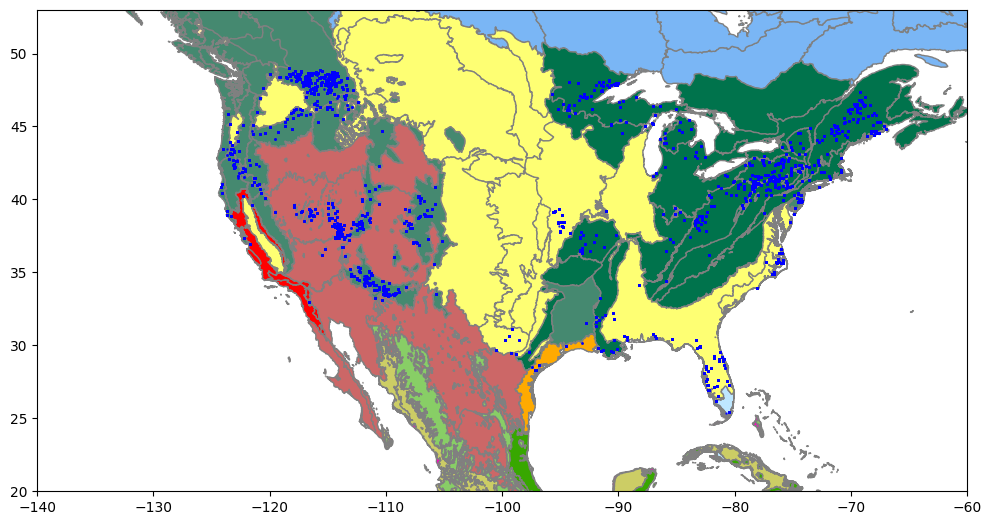

In [52]:
import geopandas as gpd
import matplotlib.pyplot as plt
# Load the shapefile

ax = na_ecoregions.plot(
    color=na_ecoregions['COLOR_BIO'],  # or use a column like 'ECO_NAME'
    edgecolor='grey',
    figsize=(12,8)
)

gdf1.plot(
    ax=ax,
    color="blue",
    markersize=0.6,
    alpha=0.8,
    legend=True
)

# Zoom to North America
ax.set_xlim(-140, -60)  # longitude
ax.set_ylim(20, 53)      # latitude

plt.show()